# TIME ANALYSIS: Are categories best?

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import warnings
import seaborn as sns
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from scipy import stats
from scipy.spatial.distance import cdist
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks, argrelextrema
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_parquet(
    r"C:\Users\lucyq\Dropbox\AMDP\THESIS\013_data_for_clustering.parquet").copy()
print('Number of accidents: ', df.shape[0],
      '\nNumber of variables:', df.shape[1])

Number of accidents:  14849 
Number of variables: 35


In [9]:
df.isnull().sum().sum()

0

In [10]:
# =============================================================================
# CREATE DAY-SPECIFIC TIME SEGMENTS
# =============================================================================

# First, ensure hour_continuous exists
df['hour_continuous'] = np.arctan2(
    df['time_sin'], df['time_cos']) * 24 / (2 * np.pi)
df['hour_continuous'] = df['hour_continuous'] % 24

# Define optimal Jenks breaks from our analysis
weekday_breaks = [0.00, 5.00, 10.05, 13.19, 16.34, 19.32, 23.99]
weekend_breaks = [0.00, 5.92, 11.08, 15.17, 19.33, 23.99]

# Create temporary day-specific labels
weekday_labels = ['Night', 'Morning', 'Late_Morning',
                  'Afternoon', 'Evening_Peak', 'Evening']
weekend_labels = ['Night', 'Morning', 'Midday', 'Afternoon', 'Evening']

# Create time segments separately for each day type (as string first)
df['time_segment'] = ''

# Weekday binning
weekday_mask = df['DAY_BINARY'] == 'Weekday'
df.loc[weekday_mask, 'time_segment'] = pd.cut(
    df.loc[weekday_mask, 'hour_continuous'],
    bins=weekday_breaks,
    labels=weekday_labels,
    include_lowest=True
).astype(str)

# Weekend binning
weekend_mask = df['DAY_BINARY'] == 'Weekend'
df.loc[weekend_mask, 'time_segment'] = pd.cut(
    df.loc[weekend_mask, 'hour_continuous'],
    bins=weekend_breaks,
    labels=weekend_labels,
    include_lowest=True
).astype(str)

# Check for any missing values
print("Missing values check:")
print(f"Empty strings: {(df['time_segment'] == '').sum()}")
print(f"NaN values: {df['time_segment'].isna().sum()}")

# If there are any empty strings or NaNs, investigate
if (df['time_segment'] == '').sum() > 0 or df['time_segment'].isna().sum() > 0:
    problematic = df[(df['time_segment'] == '') | (df['time_segment'].isna())]
    print(f"\nProblematic rows: {len(problematic)}")
    print(
        problematic[['DAY_BINARY', 'hour_continuous', 'time_segment']].head())

# Convert to categorical with only labels that exist
actual_labels = sorted(
    [label for label in df['time_segment'].unique() if label and label != 'nan'])
df['time_segment'] = pd.Categorical(
    df['time_segment'], categories=actual_labels, ordered=False)

print("="*80)
print("DAY-SPECIFIC TIME SEGMENTS")
print("="*80)

# Show distribution for each day type (filtering out zeros)
for day_type in ['Weekday', 'Weekend']:
    print(f"\n{day_type.upper()} TIME SEGMENTS:")
    subset = df[df['DAY_BINARY'] == day_type]

    # Get counts and filter out zeros
    counts = subset['time_segment'].value_counts()
    counts = counts[counts > 0].sort_index()

    for label, count in counts.items():
        pct = count / len(subset) * 100
        print(f"  {label:<20}: {count:>5} ({pct:>5.1f}%)")

    if len(counts) > 0:
        balance = counts.std() / counts.mean()
        ratio = counts.min() / counts.max()
        print(f"\n  Balance: {balance:.3f} | Min/Max ratio: {ratio:.3f}")

# Overall distribution
print("\n" + "="*80)
print("OVERALL DISTRIBUTION (All Days)")
print("="*80)
overall_counts = df['time_segment'].value_counts().sort_index()
for label, count in overall_counts.items():
    pct = count / len(df) * 100
    print(f"  {label:<20}: {count:>5} ({pct:>5.1f}%)")

# Show which labels are used by which day types
print("\n" + "="*80)
print("LABEL USAGE BY DAY TYPE")
print("="*80)
crosstab = pd.crosstab(df['DAY_BINARY'], df['time_segment'])
print(crosstab)

# Show time boundaries
print("\n" + "="*80)
print("TIME BOUNDARIES BY DAY TYPE")
print("="*80)
print("\nWEEKDAY (6 periods):")
for i, label in enumerate(weekday_labels):
    start_h, start_m = int(weekday_breaks[i]), int(
        (weekday_breaks[i] % 1) * 60)
    end_h, end_m = int(weekday_breaks[i+1]
                       ), int((weekday_breaks[i+1] % 1) * 60)
    print(f"  {label:<20}: {start_h:02d}:{start_m:02d} - {end_h:02d}:{end_m:02d}")

print("\nWEEKEND (5 periods):")
for i, label in enumerate(weekend_labels):
    start_h, start_m = int(weekend_breaks[i]), int(
        (weekend_breaks[i] % 1) * 60)
    end_h, end_m = int(weekend_breaks[i+1]
                       ), int((weekend_breaks[i+1] % 1) * 60)
    print(f"  {label:<20}: {start_h:02d}:{start_m:02d} - {end_h:02d}:{end_m:02d}")

print("\n" + "="*80)
print("READY FOR CLUSTERING")
print("="*80)
print(f"Feature: 'time_segment'")
print(f"Type: {df['time_segment'].dtype}")
print(f"Unique categories: {df['time_segment'].nunique()}")
print(f"Categories: {list(df['time_segment'].cat.categories)}")
print(f"\nNote: 'Morning' means 5-10am on weekdays, 6-11am on weekends")
print(f"      Same label, different context - clustering will learn this!")

Missing values check:
Empty strings: 0
NaN values: 0
DAY-SPECIFIC TIME SEGMENTS

WEEKDAY TIME SEGMENTS:
  Afternoon           :  1969 ( 16.0%)
  Evening             :  1943 ( 15.8%)
  Evening_Peak        :  3036 ( 24.7%)
  Late_Morning        :  2595 ( 21.2%)
  Morning             :  2543 ( 20.7%)
  Night               :   182 (  1.5%)

  Balance: 0.490 | Min/Max ratio: 0.060

WEEKEND TIME SEGMENTS:
  Afternoon           :   724 ( 28.1%)
  Evening             :   535 ( 20.7%)
  Midday              :   605 ( 23.4%)
  Morning             :   508 ( 19.7%)
  Night               :   209 (  8.1%)

  Balance: 0.370 | Min/Max ratio: 0.289

OVERALL DISTRIBUTION (All Days)
  Afternoon           :  2693 ( 18.1%)
  Evening             :  2478 ( 16.7%)
  Evening_Peak        :  3036 ( 20.4%)
  Late_Morning        :  2595 ( 17.5%)
  Midday              :   605 (  4.1%)
  Morning             :  3051 ( 20.5%)
  Night               :   391 (  2.6%)

LABEL USAGE BY DAY TYPE
time_segment  Afternoon  Eveni

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14849 entries, 0 to 14848
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype                      
---  ------                        --------------  -----                      
 0   Protocollo                    14849 non-null  int64                      
 1   total_injury_severity         14849 non-null  int32                      
 2   max_injury_severity           14849 non-null  int32                      
 3   num_pedestrians_hit           14849 non-null  int64                      
 4   num_male                      14849 non-null  int32                      
 5   num_female                    14849 non-null  int32                      
 6   num_unknown_gender            14849 non-null  int32                      
 7   multiple_pedestrians          14849 non-null  int32                      
 8   severity_winsorized           14849 non-null  int32                      
 9   DataOraIncidente 

In [12]:
# Drop the temporary columns
df.drop(columns=['hour_continuous'],
        inplace=True)

# Verify they're gone
print("Columns dropped successfully!")
print(f"New shape: {df.shape}")

Columns dropped successfully!
New shape: (14849, 36)


In [13]:
df['time_segment'].value_counts(normalize=True).round(2)

time_segment
Morning         0.21
Evening_Peak    0.20
Afternoon       0.18
Late_Morning    0.17
Evening         0.17
Midday          0.04
Night           0.03
Name: proportion, dtype: float64

In [ ]:
# Generate the crosstabulation
crosstab_result = pd.crosstab(
    df['time_segment'],
    df['DAY_BINARY'],
    margins=True  # Optional: Adds row/column totals
)

# Print the result
print(crosstab_result)

DAY_BINARY    Weekday  Weekend    All
time_segment                         
Afternoon        1969      724   2693
Evening          1943      535   2478
Evening_Peak     3036        0   3036
Late_Morning     2595        0   2595
Midday              0      605    605
Morning          2543      508   3051
Night             182      209    391
All             12268     2581  14849


# CARDINALITY CHECK

# CLUSTERING WITH TIME BINS

In [ ]:
# Numerical features for k-prototypes (continuous variables)
numerical_for_clustering = [
    # 'time_sin',
    # 'time_cos',
    'temperature_2m (°C)',
    'relative_humidity_2m (%)',
    'precipitation (mm)',
    'wind_gusts_10m (km/h)',
    'weather_days_since_last_rain',
    'male_proportion'
]

# Categorical features for k-prototypes (nominal/ordinal variables)
categorical_for_clustering = [
    'time_segment',  # Added: new time bins
    'multiple_pedestrians',
    'driver_injury',
    'driver_gender',
    'natural_light',
    'DAY_BINARY',
    'road_features',
    'road_markings_traffic_lights',
    'TipoStradaDifficulty',
    'traffic_density',
    'vehicle_type',
    'passengers',
    'road_conditions_bin',
    'road_signage',
    # 'severity_winsorized'    REMOVE SEVERITY
]

In [11]:
# =============================================================================
# CATEGORICAL FEATURE CARDINALITY ANALYSIS
# =============================================================================

print("="*80)
print("CATEGORICAL FEATURE CARDINALITY")
print("="*80)

cardinality_summary = []

for feature in categorical_for_clustering:
    n_categories = df[feature].nunique()
    n_missing = df[feature].isna().sum()
    cardinality_summary.append({
        'Feature': feature,
        'Unique_Values': n_categories,
        'Missing': n_missing,
        'Missing_%': (n_missing / len(df)) * 100
    })

cardinality_df = pd.DataFrame(cardinality_summary)
cardinality_df = cardinality_df.sort_values('Unique_Values', ascending=False)
print(cardinality_df.to_string(index=False))

# Flag high cardinality features (>10 categories)
high_cardinality = cardinality_df[cardinality_df['Unique_Values'] > 10]
if len(high_cardinality) > 0:
    print("\n" + "="*80)
    print("⚠️  HIGH CARDINALITY FEATURES (>10 categories)")
    print("="*80)
    print(high_cardinality.to_string(index=False))
    print("\nConsider consolidating these features to reduce dimensionality.")

# Show distribution for each categorical feature
print("\n" + "="*80)
print("CATEGORICAL FEATURE DISTRIBUTIONS")
print("="*80)

for feature in categorical_for_clustering:
    print(f"\n{feature.upper()}")
    print("-" * 60)
    counts = df[feature].value_counts(dropna=False)

    # Show all if <=10 categories, otherwise top 10 + tail
    if len(counts) <= 10:
        for category, count in counts.items():
            pct = (count / len(df)) * 100
            print(f"  {str(category):<40}: {count:>6} ({pct:>5.1f}%)")
    else:
        print(
            f"  Showing top 10 and bottom 3 (total categories: {len(counts)})")
        print("\n  TOP 10:")
        for category, count in counts.head(10).items():
            pct = (count / len(df)) * 100
            print(f"  {str(category):<40}: {count:>6} ({pct:>5.1f}%)")

        print("\n  BOTTOM 3:")
        for category, count in counts.tail(3).items():
            pct = (count / len(df)) * 100
            print(f"  {str(category):<40}: {count:>6} ({pct:>5.1f}%)")

# Check for features with severe imbalance (one category >90%)
print("\n" + "="*80)
print("⚠️  SEVERELY IMBALANCED FEATURES (one category >90%)")
print("="*80)

imbalanced = []
for feature in categorical_for_clustering:
    counts = df[feature].value_counts()
    if len(counts) > 0:
        max_pct = (counts.max() / len(df)) * 100
        if max_pct > 90:
            imbalanced.append({
                'Feature': feature,
                'Dominant_Category': counts.index[0],
                'Percentage': max_pct
            })

if len(imbalanced) > 0:
    imbalanced_df = pd.DataFrame(imbalanced)
    print(imbalanced_df.to_string(index=False))
    print("\nThese features may not contribute much to clustering.")
else:
    print("None found - all features have reasonable balance.")

print("\n" + "="*80)
print("RECOMMENDATION")
print("="*80)
print("Ideal cardinality for k-prototypes: 2-10 categories per feature")
print("Consider consolidating features with >10 categories")
print("Consider removing features with >90% in one category")

CATEGORICAL FEATURE CARDINALITY
                     Feature  Unique_Values  Missing  Missing_%
                time_segment              7        0        0.0
                vehicle_type              6        0        0.0
               road_features              4        0        0.0
        TipoStradaDifficulty              4        0        0.0
                road_signage              4        0        0.0
               driver_gender              3        0        0.0
               natural_light              3        0        0.0
             traffic_density              3        0        0.0
                  passengers              3        0        0.0
        multiple_pedestrians              2        0        0.0
               driver_injury              2        0        0.0
                  DAY_BINARY              2        0        0.0
road_markings_traffic_lights              2        0        0.0
         road_conditions_bin              2        0        0.0

CATEGOR

In [12]:
df_clustering = df[numerical_for_clustering + categorical_for_clustering]

In [13]:
df_clustering.shape

(14849, 20)

# FUNCTIONS FOR K-PROTOTYPES CLUSTERING

### FUNCTIONS FOR CLUSTER FITTING & EVALUATING

In [14]:
###############################
# PREPROCESSING DATA FUNCTION #
###############################

def preprocess_data(df, categorical_cols, numerical_cols):
    """
    Efficient preprocessing for K-Prototypes:
    - Categoricals: OrdinalEncoder → int32
    - Numericals: StandardScaler → float32
    """
    # Categorical encoding
    df_cat = df[categorical_cols].copy()
    df_cat = df_cat.astype("object").fillna("(missing)")

    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_cat = enc.fit_transform(df_cat)
    X_cat = np.where(np.isnan(X_cat), -1, X_cat)
    X_cat = X_cat.astype(np.int32, copy=False)

    # Create category mappings for later interpretation
    cat_maps = {col: {cat: i for i, cat in enumerate(enc.categories_[j])}
                for j, col in enumerate(categorical_cols)}
    rev_maps = {col: {i: cat for i, cat in enumerate(enc.categories_[j])}
                for j, col in enumerate(categorical_cols)}
    for col in categorical_cols:
        rev_maps[col][-1] = None

    # Numerical standardization
    X_num = df[numerical_cols].apply(pd.to_numeric, errors="coerce")
    num_medians = X_num.median(numeric_only=True)
    X_num = X_num.fillna(num_medians)

    scaler = StandardScaler()
    X_num_scaled = scaler.fit_transform(X_num).astype(np.float32, copy=False)

    # Combine: categoricals FIRST (critical for K-Prototypes)
    X = np.concatenate(
        [X_cat.astype(np.float32, copy=False), X_num_scaled], axis=1)
    categorical_indices = list(range(len(categorical_cols)))

    # Sanity checks
    assert X.dtype == np.float32, f"Expected float32, got {X.dtype}"
    assert np.isfinite(X).all(), "X contains NaN or inf values"

    print(f"\n✓ Preprocessing complete:")
    print(f"  Shape: {X.shape}")
    print(f"  Categorical features: {len(categorical_indices)}")
    print(f"  Numerical features: {len(numerical_cols)}")
    print(f"  dtype: {X.dtype}")

    return X, categorical_indices, enc, scaler, num_medians, rev_maps

##################
# ELBOW ANALYSIS #
##################


def elbow_analysis(X, categorical_indices, k_range, sample_size=df.shape[0], random_state=42):
    """
    Run K-Prototypes for multiple k values to find elbow point.
    Uses sampling to speed up computation.
    """
    # Sample data for faster computation
    rng = np.random.RandomState(random_state)
    n_samples = min(sample_size, X.shape[0])
    idx = rng.choice(X.shape[0], size=n_samples, replace=False)
    X_sample = X[idx]

    print(f"Using {n_samples} samples for elbow analysis...")

    costs = []
    for k in k_range:
        print(f"  Running k={k}...", end=" ")
        kp = KPrototypes(
            n_clusters=k,
            init="Cao",
            n_init=1,
            max_iter=20,
            random_state=random_state,
            verbose=0
        )
        kp.fit_predict(X_sample, categorical=categorical_indices)
        costs.append(kp.cost_)
        print(f"Cost: {kp.cost_:.2f}")

    # Calculate relative improvement
    cost_series = pd.Series(costs, index=k_range, name="cost")
    rel_improve = (-cost_series.diff() / cost_series.shift(1)
                   ).rename("rel_improve")
    elbow_df = pd.concat([cost_series, rel_improve], axis=1)

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 2))

    ax1.plot(k_range, costs, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
    ax1.set_ylabel('Cost', fontsize=12)
    ax1.set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    ax2.plot(k_range[1:], rel_improve[1:], 'ro-', linewidth=2, markersize=8)
    ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
    ax2.set_ylabel('Relative Improvement', fontsize=12)
    ax2.set_title('Cost Reduction Rate', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0.05, color='green', linestyle='--',
                alpha=0.5, label='5% threshold')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return elbow_df

################
# GAMMA TUNING #
################


def gamma_tuning(X, categorical_indices, gammas, k=7, n_init=3, random_state=42):
    """
    Test different gamma values to balance categorical vs numerical importance.
    Higher gamma = more weight on categorical features.
    """
    print(f"Testing {len(gammas)} gamma values for k={k}...")

    results = []
    for g in gammas:
        print(f"  γ={g:.2f}...", end=" ")
        model = KPrototypes(
            n_clusters=k,
            init="Cao",
            n_init=n_init,
            max_iter=50,
            verbose=0,
            random_state=random_state,
            gamma=g
        )
        labels = model.fit_predict(X, categorical=categorical_indices)
        cost = model.cost_
        results.append({"gamma": g, "cost": cost})
        print(f"Cost: {cost:.2f}")

    results_df = pd.DataFrame(results).sort_values("cost")

    # Plot
    plt.figure(figsize=(8, 3))
    plt.plot(results_df['gamma'], results_df['cost'],
             'go-', linewidth=2, markersize=8)
    plt.xlabel('Gamma (γ)', fontsize=12)
    plt.ylabel('Cost', fontsize=12)
    plt.title('Gamma Tuning: Cost vs γ', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.show()

    return results_df

##################
# FIT & EVALUATE #
##################


def fit_and_evaluate(X, categorical_indices, k, gamma, enc, random_state=42):
    """
    Fit K-Prototypes and calculate multiple quality metrics.
    """
    print(f"\nFitting K-Prototypes: k={k}, γ={gamma}")
    print("This may take several minutes...")

    kproto = KPrototypes(
        n_clusters=k,
        init="Cao",
        gamma=gamma,
        n_init=5,
        max_iter=100,
        random_state=random_state,
        verbose=1
    )
    labels = kproto.fit_predict(X, categorical=categorical_indices)

    # Calculate metrics
    metrics = {}
    metrics['cost'] = kproto.cost_
    metrics['n_iter'] = kproto.n_iter_

    # Sample for silhouette (too slow on full dataset)
    sample_size = min(5000, X.shape[0])
    rng = np.random.RandomState(random_state)
    idx = rng.choice(X.shape[0], size=sample_size, replace=False)

    print("\nCalculating quality metrics (using sample)...")

    # Gower distance approximation for mixed data
    # Use only numerical features for standard metrics
    n_cat = len(categorical_indices)
    X_num = X[:, n_cat:]

    try:
        metrics['silhouette'] = silhouette_score(X_num[idx], labels[idx])
        metrics['calinski_harabasz'] = calinski_harabasz_score(X_num, labels)
        metrics['davies_bouldin'] = davies_bouldin_score(X_num, labels)
    except Exception as e:
        print(f"Warning: Could not calculate some metrics: {e}")
        metrics['silhouette'] = np.nan
        metrics['calinski_harabasz'] = np.nan
        metrics['davies_bouldin'] = np.nan

    # Cluster size balance
    sizes = pd.Series(labels).value_counts().sort_index()
    metrics['size_ratio'] = sizes.max() / sizes.min()
    metrics['min_cluster_size'] = sizes.min()
    metrics['max_cluster_size'] = sizes.max()

    print("\n" + "="*50)
    print("CLUSTERING QUALITY METRICS")
    print("="*50)
    print(f"Cost:                    {metrics['cost']:.2f}")
    print(f"Iterations:              {metrics['n_iter']}")
    print(
        f"Silhouette Score:        {metrics['silhouette']:.4f} (higher is better: -1 to 1)")
    print(
        f"Calinski-Harabasz:       {metrics['calinski_harabasz']:.2f} (higher is better)")
    print(
        f"Davies-Bouldin:          {metrics['davies_bouldin']:.4f} (lower is better)")
    print(f"Size Ratio (max/min):    {metrics['size_ratio']:.2f}")
    print(f"Cluster Sizes:           {sizes.min()} to {sizes.max()}")
    print("="*50)

    return kproto, labels, metrics, sizes

### FUNCTIONS FOR DECODING AND VIEWING CLUSTERS

In [15]:

####################
# DECODE CENTROIDS #
####################

def decode_centroids(kproto, enc, scaler, categorical_cols, numerical_cols, rev_maps):
    """
    Decode K-Prototypes centroids to interpretable format.

    Parameters:
    - kproto: Fitted KPrototypes model
    - enc: OrdinalEncoder used for categorical features
    - scaler: StandardScaler used for numerical features
    - categorical_cols: List of categorical column names
    - numerical_cols: List of numerical column names
    - rev_maps: Reverse mapping dictionary for categorical features
    """
    cc = kproto.cluster_centroids_
    n_cat = len(categorical_cols)
    n_num = len(numerical_cols)

    # KPrototypes stores centroids as [NUMERICAL, CATEGORICAL] regardless of input order!
    num_centroids = np.asarray(cc)[:, :n_num].astype(
        float)     # First n_num columns
    # Last n_cat columns
    cat_centroids = np.asarray(cc)[:, n_num:]

    # Inverse transform numerical centroids back to original scale
    num_centroids_original = scaler.inverse_transform(num_centroids)

    # Numerical centroids (rounded to 2 decimal places)
    num_centroids_df = pd.DataFrame(
        np.round(num_centroids_original, 2),
        columns=numerical_cols
    )

    # Decode categorical centroids - UPDATED VERSION
    def decode_cat(col, v):
        if pd.isna(v):
            return "(missing)"
        try:
            vi = int(round(float(v)))
        except:
            return "(missing)"

        decoded = rev_maps.get(col, {}).get(vi, "(missing)")

        # Convert None to a string
        if decoded is None:
            return "(missing)"

        # Convert everything to string for consistency
        return str(decoded)

    cat_centroids_df = pd.DataFrame({
        col: [decode_cat(col, v) for v in cat_centroids[:, j]]
        for j, col in enumerate(categorical_cols)
    })

    centroids_df = pd.concat([cat_centroids_df, num_centroids_df], axis=1)
    centroids_df.index.name = "cluster_id"

    return centroids_df

##########################
# CREATE CLUSTER SUMMARY #
##########################


def create_cluster_summary(df_enc, categorical_cols, numerical_cols):
    """
    Create comprehensive cluster summary statistics.
    """
    # Numerical means
    num_summary = df_enc.groupby("cluster_id")[numerical_cols].mean()

    # Categorical modes
    mode_summary = df_enc.groupby("cluster_id")[categorical_cols].agg(
        lambda s: s.value_counts(dropna=False).idxmax()
    )

    # Top 3 proportions for each categorical
    def top3_props(s):
        vc = s.value_counts(dropna=False, normalize=True)
        return " | ".join([f"{k}: {p:.1%}" for k, p in vc.head(3).items()])

    top3_summary = df_enc.groupby("cluster_id")[
        categorical_cols].agg(top3_props)

    # Combine
    summary = num_summary.join(mode_summary, rsuffix='_mode')

    return summary, top3_summary

#########################
# TOP LIFTS FOR CLUSTER #
#########################


def top_lifts_for_cluster(df_enc, cluster_id, cat_cols, topn=8, min_prop=0.07):
    """
    Identify distinctive categorical features for each cluster using lift.
    Lift = (proportion in cluster) / (proportion overall)
    """
    dfc = df_enc[df_enc["cluster_id"] == cluster_id]
    out = []

    for col in cat_cols:
        glob = df_enc[col].value_counts(normalize=True, dropna=False)
        clus = dfc[col].value_counts(normalize=True, dropna=False)

        for val, p_c in clus.items():
            p_g = glob.get(val, 0.0)
            if p_c >= min_prop and p_g > 0:
                lift = p_c / p_g
                out.append({
                    'feature': col,
                    'value': val,
                    'cluster_prop': round(p_c, 2),
                    'overall_prop': round(p_g, 2),
                    'lift': round(lift, 2)
                })

    lift_df = pd.DataFrame(out).sort_values(['lift', 'cluster_prop'],
                                            ascending=[False, False])
    return lift_df.head(topn)

# CLUSTERING WITH TIME BINS

## 

In [16]:
print("="*70)
print("K-PROTOTYPES CLUSTERING - PEDESTRIAN ACCIDENTS IN ROME")
print("="*70)

# Run preprocessing
X, categorical_indices, enc, scaler, num_medians, rev_maps = preprocess_data(
    df_clustering, categorical_for_clustering, numerical_for_clustering)

K-PROTOTYPES CLUSTERING - PEDESTRIAN ACCIDENTS IN ROME

✓ Preprocessing complete:
  Shape: (14849, 20)
  Categorical features: 14
  Numerical features: 6
  dtype: float32



ELBOW METHOD - Finding Optimal K
Using 14849 samples for elbow analysis...
  Running k=4... Cost: 80673.34
  Running k=5... Cost: 72382.12
  Running k=6... Cost: 67883.13
  Running k=7... Cost: 63944.29
  Running k=8... Cost: 61960.16
  Running k=9... Cost: 59977.07


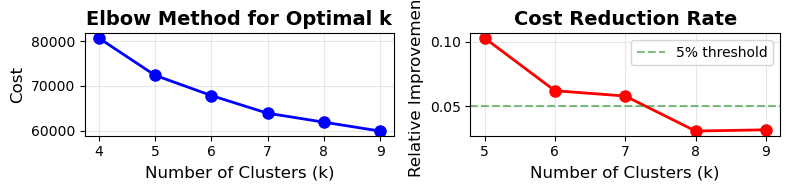


Elbow Analysis Results:
           cost  rel_improve
4  80673.339824          NaN
5  72382.118093     0.102775
6  67883.131472     0.062156
7  63944.293184     0.058024
8  61960.156121     0.031029
9  59977.069314     0.032006

Sorted by Relative Improvement:
           cost  rel_improve
5  72382.118093     0.102775
6  67883.131472     0.062156
7  63944.293184     0.058024
9  59977.069314     0.032006
8  61960.156121     0.031029
4  80673.339824          NaN


In [17]:
print("\n" + "="*70)
print("ELBOW METHOD - Finding Optimal K")
print("="*70)

# Run elbow analysis
K_range = list(range(4, 10))
elbow_df = elbow_analysis(X, categorical_indices, K_range)

print("\nElbow Analysis Results:")
print(elbow_df)
print("\nSorted by Relative Improvement:")
print(elbow_df.sort_values("rel_improve", ascending=False))

Given these results, we choose k = 7, as the marginal drops in cost fall below 5% after k=7. 

In [24]:
chosen_k = 7


GAMMA TUNING
Testing 5 gamma values for k=7...
  γ=0.50... Cost: 63906.43
  γ=1.00... Cost: 92142.90
  γ=1.50... Cost: 120346.50
  γ=2.00... Cost: 147372.11
  γ=2.50... Cost: 174774.87


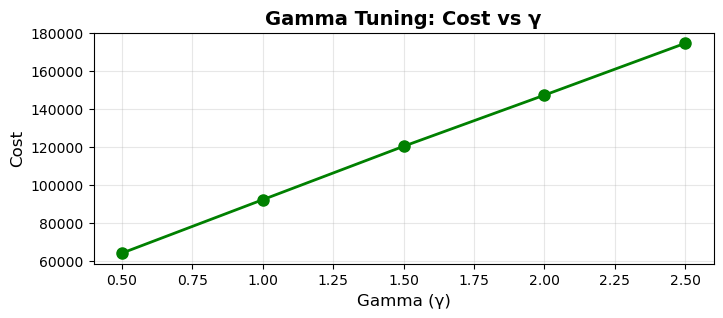


Gamma Tuning Results:
   gamma           cost
0    0.5   63906.427402
1    1.0   92142.904391
2    1.5  120346.498955
3    2.0  147372.114616
4    2.5  174774.872743


In [25]:
print("\n" + "="*70)
print("GAMMA TUNING")
print("="*70)

# Run gamma tuning (adjust k based on elbow results)
gammas = np.linspace(0.5, 2.5, 5)
gamma_results = gamma_tuning(X, categorical_indices, gammas, k=chosen_k)
print("\nGamma Tuning Results:")
print(gamma_results)

In [26]:
print("\n" + "="*70)
print("FINAL CLUSTERING & QUALITY ASSESSMENT")
print("="*70)

# Set your chosen gamma
chosen_gamma = 1.5  # Update based on gamma tuning

kproto, labels, metrics, cluster_sizes = fit_and_evaluate(
    X, categorical_indices, chosen_k, chosen_gamma, enc
)

# Add labels to dataframe
df_enc = df.copy()
df_enc["cluster_id"] = labels

print("\nCluster Sizes:")
print(cluster_sizes)


FINAL CLUSTERING & QUALITY ASSESSMENT

Fitting K-Prototypes: k=7, γ=1.5
This may take several minutes...
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 7477, ncost: 126452.59566029413
Run: 1, iteration: 2/100, moves: 3337, ncost: 123233.47059901195
Run: 1, iteration: 3/100, moves: 2151, ncost: 121391.89313817756
Run: 1, iteration: 4/100, moves: 1221, ncost: 120721.90794462735
Run: 1, iteration: 5/100, moves: 606, ncost: 120516.76040289998
Run: 1, iteration: 6/100, moves: 366, ncost: 120453.05972339648
Run: 1, iteration: 7/100, moves: 232, ncost: 120420.97933224536
Run: 1, iteration: 8/100, moves: 197, ncost: 120396.76316989395
Run: 1, iteration: 9/100, moves: 164, ncost: 120379.9110574773
Run: 1, iteration: 10/100, moves: 147, ncost: 120365.62074235234
Run: 1, iteration: 11/100, moves: 125, ncost: 120354.53794900954
Run: 1, iteration: 12/100, mo

In [27]:
print("\n" + "="*70)
print("CLUSTER INTERPRETATION")
print("="*70)

centroids_pretty = decode_centroids(
    kproto, enc, scaler, categorical_for_clustering, numerical_for_clustering, rev_maps)
print("\nCluster Centroids:")
print(centroids_pretty.T)


CLUSTER INTERPRETATION

Cluster Centroids:
cluster_id                                0              1              2  \
time_segment                        Morning        Evening   Evening_Peak   
multiple_pedestrians                      0              0              0   
driver_injury                             0              0              0   
driver_gender                             M              M              M   
natural_light                     light_day    light_night      light_day   
DAY_BINARY                          Weekday        Weekday        Weekday   
road_features                 Straight road  Straight road  Straight road   
road_markings_traffic_lights              0              0              0   
TipoStradaDifficulty                      2              2              2   
traffic_density                           1              0              1   
vehicle_type                            Car            Car            Car   
passengers                      

In [ ]:
summary, top3_summary = create_cluster_summary(
    df_enc, categorical_for_clustering, numerical_for_clustering)

print("\nTop 3 Categories per Cluster:")
print(top3_summary.T)


Cluster Summary (Numerical Means + Categorical Modes):
cluster_id                                0              1              2  \
temperature_2m (°C)               13.903946      13.623667      15.465871   
relative_humidity_2m (%)          74.122766      83.456111      69.717184   
precipitation (mm)                  0.05801       0.065167       0.002029   
wind_gusts_10m (km/h)             19.814503      13.390222      16.805489   
weather_days_since_last_rain        1.69688       1.898958       14.11973   
male_proportion                    0.989236       0.795657       0.458433   
time_segment                        Morning        Evening   Evening_Peak   
multiple_pedestrians                      0              0              0   
driver_injury                             0              0              0   
driver_gender                             M              M              M   
natural_light                     light_day    light_night      light_day   
DAY_BINARY          

In [29]:
print("\n" + "="*70)
print("DISTINCTIVE FEATURES BY CLUSTER (Lift Analysis)")
print("="*70)

distinctive = {
    k: top_lifts_for_cluster(df_enc, k, categorical_for_clustering)
    for k in sorted(df_enc["cluster_id"].unique())
}

for cluster_id, lift_df in distinctive.items():
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster_id} - Most Distinctive Features")
    print(f"{'='*50}")
    print(lift_df.to_string(index=False))


DISTINCTIVE FEATURES BY CLUSTER (Lift Analysis)

CLUSTER 0 - Most Distinctive Features
            feature          value  cluster_prop  overall_prop  lift
       time_segment        Morning          0.36          0.21  1.76
    traffic_density              2          0.11          0.09  1.17
      driver_injury              1          0.08          0.07  1.16
      natural_light light_twilight          0.18          0.16  1.15
      natural_light      light_day          0.79          0.69  1.14
    traffic_density              1          0.75          0.67  1.11
       road_signage         onroad          0.15          0.14  1.11
road_conditions_bin              1          0.26          0.24  1.10

CLUSTER 1 - Most Distinctive Features
             feature          value  cluster_prop  overall_prop  lift
        time_segment          Night          0.16          0.03  6.01
       natural_light    light_night          0.74          0.15  4.85
        time_segment        Evening       

# Traffic Incident Cluster Analysis Summary
Time segments in, severity out

K-Prototypes  
k                           7  
gamma                       1.5  
Cost:                       120346.50
Iterations:                 17
Silhouette Score:           0.1453 (higher is better: -1 to 1)      Poor separation
Calinski-Harabasz:          2862.87 (higher is better)              Worse
Davies-Bouldin:             1.8809 (lower is better)                Worse
Size Ratio (max/min):       5.85                                    Imbalance better
Cluster Sizes:              622 to 3637

In [30]:
print("\n" + "="*70)
print("EXPORTING RESULTS")
print("="*70)

# Save summary
output_path = r"C:\Users\lucyq\Dropbox\AMDP\THESIS\k7-g15-Timebins_no_severity.xlsx"
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    summary.to_excel(writer, sheet_name='Summary')
    top3_summary.to_excel(writer, sheet_name='Top3_Proportions')
    centroids_pretty.to_excel(writer, sheet_name='Centroids')
    pd.DataFrame([metrics]).to_excel(writer, sheet_name='Metrics', index=False)
    cluster_sizes.to_frame('size').to_excel(writer, sheet_name='Cluster_Sizes')

print(f"✓ Results saved to: {output_path}")

# Save cluster assignments
df_enc[['cluster_id']].to_csv(
    r"C:\Users\lucyq\Dropbox\AMDP\THESIS\cluster_k7-g15-Timebins_no_severity.csv"
)
print("✓ Cluster assignments saved")

print("\n" + "="*70)
print("CLUSTERING COMPLETE!")
print("="*70)


EXPORTING RESULTS
✓ Results saved to: C:\Users\lucyq\Dropbox\AMDP\THESIS\k7-g15-Timebins_no_severity.xlsx
✓ Cluster assignments saved

CLUSTERING COMPLETE!


## REMOVING REDUNDANT FEATURES

The features which are continuously coming out the same for every cluster are:
- multiple pedestrians
- driver injury
- road features
- road markings traffic lights
- passengers
- road signage

We will try removing these features from the dataframe and reclustering:

In [ ]:
# Numerical features for k-prototypes (continuous variables)
numerical_for_clustering = [
    # 'time_sin',
    # 'time_cos',
    'temperature_2m (°C)',
    'relative_humidity_2m (%)',
    'precipitation (mm)',
    'wind_gusts_10m (km/h)',
    'weather_days_since_last_rain',
    'male_proportion'
]

# Categorical features for k-prototypes (nominal/ordinal variables)
categorical_for_clustering = [
    'time_segment',  # Added: new time bins
    # 'multiple_pedestrians',
    # 'driver_injury',
    'driver_gender',
    'natural_light',
    'DAY_BINARY',
    # 'road_features',
    # 'road_markings_traffic_lights',
    'TipoStradaDifficulty',
    'traffic_density',
    'vehicle_type',
    # 'passengers',
    'road_conditions_bin',
    # 'road_signage',
    # 'severity_winsorized'     REMOVE SEVERITY
]

In [32]:
df_clustering = df[numerical_for_clustering + categorical_for_clustering]

In [33]:
df_clustering.shape

(14849, 14)

In [34]:
print("="*70)
print("K-PROTOTYPES CLUSTERING - PEDESTRIAN ACCIDENTS IN ROME")
print("="*70)

# Run preprocessing
X, categorical_indices, enc, scaler, num_medians, rev_maps = preprocess_data(
    df_clustering, categorical_for_clustering, numerical_for_clustering)

K-PROTOTYPES CLUSTERING - PEDESTRIAN ACCIDENTS IN ROME

✓ Preprocessing complete:
  Shape: (14849, 14)
  Categorical features: 8
  Numerical features: 6
  dtype: float32



ELBOW METHOD - Finding Optimal K
Using 14849 samples for elbow analysis...
  Running k=4... Cost: 73477.84
  Running k=5... Cost: 65186.62
  Running k=6... Cost: 60687.63
  Running k=7... Cost: 56748.79
  Running k=8... Cost: 54735.40
  Running k=9... Cost: 52781.41


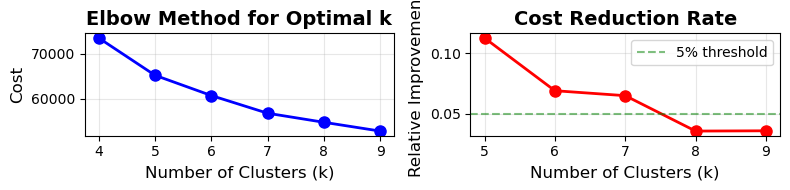


Elbow Analysis Results:
           cost  rel_improve
4  73477.839819          NaN
5  65186.618088     0.112840
6  60687.629050     0.069017
7  56748.793179     0.064903
8  54735.404375     0.035479
9  52781.405972     0.035699

Sorted by Relative Improvement:
           cost  rel_improve
5  65186.618088     0.112840
6  60687.629050     0.069017
7  56748.793179     0.064903
9  52781.405972     0.035699
8  54735.404375     0.035479
4  73477.839819          NaN


In [35]:
print("\n" + "="*70)
print("ELBOW METHOD - Finding Optimal K")
print("="*70)

# Run elbow analysis
K_range = list(range(4, 10))
elbow_df = elbow_analysis(X, categorical_indices, K_range)

print("\nElbow Analysis Results:")
print(elbow_df)
print("\nSorted by Relative Improvement:")
print(elbow_df.sort_values("rel_improve", ascending=False))

Given these results, we again choose k = 7, as the marginal drops in cost fall below 5% after k=7. 

In [36]:
chosen_k = 7


GAMMA TUNING
Testing 5 gamma values for k=7...
  γ=0.50... Cost: 56725.98
  γ=1.00... Cost: 77496.65
  γ=1.50... Cost: 98247.67
  γ=2.00... Cost: 120053.42
  γ=2.50... Cost: 138121.27


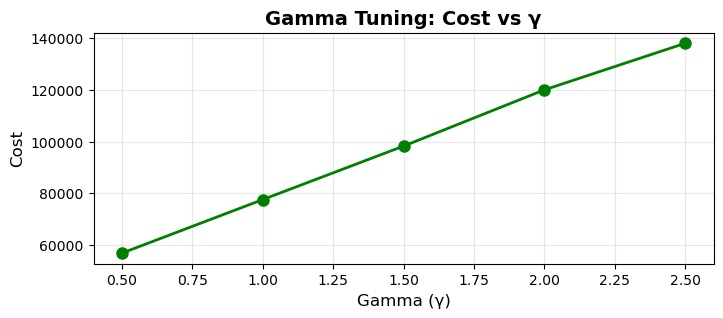


Gamma Tuning Results:
   gamma           cost
0    0.5   56725.978687
1    1.0   77496.652772
2    1.5   98247.673942
3    2.0  120053.421645
4    2.5  138121.266093


In [37]:
print("\n" + "="*70)
print("GAMMA TUNING")
print("="*70)

# Run gamma tuning (adjust k based on elbow results)
gammas = np.linspace(0.5, 2.5, 5)
gamma_results = gamma_tuning(X, categorical_indices, gammas, k=chosen_k)
print("\nGamma Tuning Results:")
print(gamma_results)

In [38]:
print("\n" + "="*70)
print("FINAL CLUSTERING & QUALITY ASSESSMENT")
print("="*70)

# Set your chosen gamma
chosen_gamma = 1.5  # Update based on gamma tuning

kproto, labels, metrics, cluster_sizes = fit_and_evaluate(
    X, categorical_indices, chosen_k, chosen_gamma, enc
)

# Add labels to dataframe
df_enc = df.copy()
df_enc["cluster_id"] = labels

print("\nCluster Sizes:")
print(cluster_sizes)


FINAL CLUSTERING & QUALITY ASSESSMENT

Fitting K-Prototypes: k=7, γ=1.5
This may take several minutes...
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 6941, ncost: 105937.77040045362
Run: 1, iteration: 2/100, moves: 3405, ncost: 102364.4173106939
Run: 1, iteration: 3/100, moves: 1887, ncost: 100410.48260830627
Run: 1, iteration: 4/100, moves: 1162, ncost: 99469.6075270427
Run: 1, iteration: 5/100, moves: 482, ncost: 99270.84030259843
Run: 1, iteration: 6/100, moves: 278, ncost: 99212.04820893267
Run: 1, iteration: 7/100, moves: 179, ncost: 99194.52254612953
Run: 1, iteration: 8/100, moves: 160, ncost: 99182.81522814806
Run: 1, iteration: 9/100, moves: 72, ncost: 99179.85868870607
Run: 1, iteration: 10/100, moves: 75, ncost: 99176.86212625947
Run: 1, iteration: 11/100, moves: 78, ncost: 99173.1715967015
Run: 1, iteration: 12/100, moves: 71, ncos

In [39]:
print("\n" + "="*70)
print("CLUSTER INTERPRETATION")
print("="*70)

centroids_pretty = decode_centroids(
    kproto, enc, scaler, categorical_for_clustering, numerical_for_clustering, rev_maps)
print("\nCluster Centroids:")
print(centroids_pretty.T)


CLUSTER INTERPRETATION

Cluster Centroids:
cluster_id                            0             1             2  \
time_segment                    Morning  Evening_Peak  Late_Morning   
driver_gender                         M             M             M   
natural_light                 light_day     light_day     light_day   
DAY_BINARY                      Weekday       Weekday       Weekday   
TipoStradaDifficulty                  2             2             2   
traffic_density                       1             1             1   
vehicle_type                        Car           Car           Car   
road_conditions_bin                   0             0             0   
temperature_2m (°C)               13.18         15.26         24.07   
relative_humidity_2m (%)          79.43         70.63          50.1   
precipitation (mm)                 0.04           0.0          0.01   
wind_gusts_10m (km/h)              15.1         16.27         25.84   
weather_days_since_last_rain     

In [ ]:
summary, top3_summary = create_cluster_summary(
    df_enc, categorical_for_clustering, numerical_for_clustering)

print("\nTop 3 Categories per Cluster:")
print(top3_summary.T)


Cluster Summary (Numerical Means + Categorical Modes):
cluster_id                            0             1             2  \
temperature_2m (°C)           13.181813     15.258625     24.066268   
relative_humidity_2m (%)      79.429402     70.632087     50.104595   
precipitation (mm)             0.043463       0.00193      0.008928   
wind_gusts_10m (km/h)         15.100668     16.265018     25.841913   
weather_days_since_last_rain    1.92255     14.162947      2.937772   
male_proportion                0.982331      0.464013      0.017121   
time_segment                    Morning  Evening_Peak  Late_Morning   
driver_gender                         M             M             M   
natural_light                 light_day     light_day     light_day   
DAY_BINARY                      Weekday       Weekday       Weekday   
TipoStradaDifficulty                  2             2             2   
traffic_density                       1             1             1   
vehicle_type         

In [41]:
print("\n" + "="*70)
print("DISTINCTIVE FEATURES BY CLUSTER (Lift Analysis)")
print("="*70)

distinctive = {
    k: top_lifts_for_cluster(df_enc, k, categorical_for_clustering)
    for k in sorted(df_enc["cluster_id"].unique())
}

for cluster_id, lift_df in distinctive.items():
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster_id} - Most Distinctive Features")
    print(f"{'='*50}")
    print(lift_df.to_string(index=False))


DISTINCTIVE FEATURES BY CLUSTER (Lift Analysis)

CLUSTER 0 - Most Distinctive Features
             feature                 value  cluster_prop  overall_prop  lift
       natural_light           light_night          0.28          0.15  1.85
        time_segment               Evening          0.26          0.17  1.57
        time_segment               Morning          0.29          0.21  1.43
       natural_light        light_twilight          0.22          0.16  1.40
     traffic_density                     0          0.30          0.23  1.29
          DAY_BINARY               Weekend          0.20          0.17  1.14
TipoStradaDifficulty                     4          0.08          0.07  1.09
        vehicle_type Motorcycle_or_scooter          0.22          0.21  1.04

CLUSTER 1 - Most Distinctive Features
             feature                 value  cluster_prop  overall_prop  lift
 road_conditions_bin                     0          0.98          0.76  1.28
       natural_light      

# Traffic Incident Cluster Analysis Summary
Time segments in, features removed: multiple pedestrians, driver injury, road features, road markings traffic lights, passengers, road signage

K-Prototypes  
k                           7  
gamma                       1.5  
Cost:                       98172.04
Iterations:                 28
Silhouette Score:           0.2399 (higher is better: -1 to 1)      Moderate separation
Calinski-Harabasz:          3506.95 (higher is better)
Davies-Bouldin:             1.2517 (lower is better)
Size Ratio (max/min):       7.56                                    Moderate size imbalance
Cluster Sizes:              455 to 3442

This made the clustering worse, not better! 

In [42]:
print("\n" + "="*70)
print("EXPORTING RESULTS")
print("="*70)

# Save summary
output_path = r"C:\Users\lucyq\Dropbox\AMDP\THESIS\k7-g15-features_removed_severity_out.xlsx"
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    summary.to_excel(writer, sheet_name='Summary')
    top3_summary.to_excel(writer, sheet_name='Top3_Proportions')
    centroids_pretty.to_excel(writer, sheet_name='Centroids')
    pd.DataFrame([metrics]).to_excel(writer, sheet_name='Metrics', index=False)
    cluster_sizes.to_frame('size').to_excel(writer, sheet_name='Cluster_Sizes')

print(f"✓ Results saved to: {output_path}")

# Save cluster assignments
df_enc[['cluster_id']].to_csv(
    r"C:\Users\lucyq\Dropbox\AMDP\THESIS\cluster_k7-g15-features_removed_severity_out.csv"
)
print("✓ Cluster assignments saved")

print("\n" + "="*70)
print("CLUSTERING COMPLETE!")
print("="*70)


EXPORTING RESULTS
✓ Results saved to: C:\Users\lucyq\Dropbox\AMDP\THESIS\k7-g15-features_removed_severity_out.xlsx
✓ Cluster assignments saved

CLUSTERING COMPLETE!


## REMOVING MORE FEATURES

The features which are continuously coming out the same for every cluster are:
- vehicle type
- traffic density
- tipo strada difficulty
- driver gender

We will try removing these features from the dataframe and reclustering:

In [ ]:
# Numerical features for k-prototypes (continuous variables)
numerical_for_clustering = [
    # 'time_sin',
    # 'time_cos',
    'temperature_2m (°C)',
    'relative_humidity_2m (%)',
    'precipitation (mm)',
    'wind_gusts_10m (km/h)',
    'weather_days_since_last_rain',
    'male_proportion'
]

# Categorical features for k-prototypes (nominal/ordinal variables)
categorical_for_clustering = [
    'time_segment',  # Added: new time bins
    # 'multiple_pedestrians',
    # 'driver_injury',
    # 'driver_gender',
    'natural_light',
    'DAY_BINARY',
    # 'road_features',
    # 'road_markings_traffic_lights',
    # 'TipoStradaDifficulty',
    # 'traffic_density',
    # 'vehicle_type',
    # 'passengers',
    'road_conditions_bin',
    # 'road_signage',
    # 'severity_winsorized'    REMOVE SEVERITY
]

In [45]:
df_clustering = df[numerical_for_clustering + categorical_for_clustering]

In [46]:
df_clustering.shape

(14849, 10)

In [47]:
print("="*70)
print("K-PROTOTYPES CLUSTERING - PEDESTRIAN ACCIDENTS IN ROME")
print("="*70)

# Run preprocessing
X, categorical_indices, enc, scaler, num_medians, rev_maps = preprocess_data(
    df_clustering, categorical_for_clustering, numerical_for_clustering)

K-PROTOTYPES CLUSTERING - PEDESTRIAN ACCIDENTS IN ROME

✓ Preprocessing complete:
  Shape: (14849, 10)
  Categorical features: 4
  Numerical features: 6
  dtype: float32



ELBOW METHOD - Finding Optimal K
Using 14849 samples for elbow analysis...
  Running k=4... Cost: 62771.34
  Running k=5... Cost: 54480.12
  Running k=6... Cost: 49981.13
  Running k=7... Cost: 46042.29
  Running k=8... Cost: 44031.96
  Running k=9... Cost: 42074.91


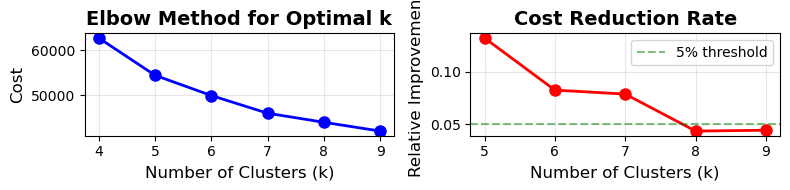


Elbow Analysis Results:
           cost  rel_improve
4  62771.339812          NaN
5  54480.118081     0.132086
6  49981.129043     0.082580
7  46042.293173     0.078806
8  44031.962326     0.043663
9  42074.910811     0.044446

Sorted by Relative Improvement:
           cost  rel_improve
5  54480.118081     0.132086
6  49981.129043     0.082580
7  46042.293173     0.078806
9  42074.910811     0.044446
8  44031.962326     0.043663
4  62771.339812          NaN


In [48]:
print("\n" + "="*70)
print("ELBOW METHOD - Finding Optimal K")
print("="*70)

# Run elbow analysis
K_range = list(range(4, 10))
elbow_df = elbow_analysis(X, categorical_indices, K_range)

print("\nElbow Analysis Results:")
print(elbow_df)
print("\nSorted by Relative Improvement:")
print(elbow_df.sort_values("rel_improve", ascending=False))

Given these results, we again choose k = 7, as the marginal drops in cost fall below 5% after k=7. 

In [49]:
chosen_k = 7


GAMMA TUNING
Testing 5 gamma values for k=7...
  γ=0.50... Cost: 46011.02
  γ=1.00... Cost: 56070.29
  γ=1.50... Cost: 66869.53
  γ=2.00... Cost: 75676.83
  γ=2.50... Cost: 84117.43


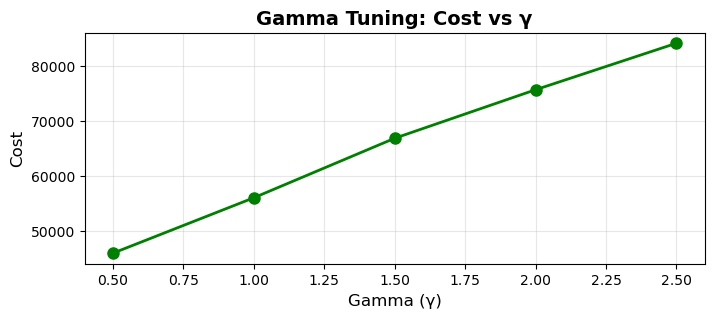


Gamma Tuning Results:
   gamma          cost
0    0.5  46011.018236
1    1.0  56070.290299
2    1.5  66869.525885
3    2.0  75676.825598
4    2.5  84117.426220


In [50]:
print("\n" + "="*70)
print("GAMMA TUNING")
print("="*70)

# Run gamma tuning (adjust k based on elbow results)
gammas = np.linspace(0.5, 2.5, 5)
gamma_results = gamma_tuning(X, categorical_indices, gammas, k=chosen_k)
print("\nGamma Tuning Results:")
print(gamma_results)

In [51]:
print("\n" + "="*70)
print("FINAL CLUSTERING & QUALITY ASSESSMENT")
print("="*70)

# Set your chosen gamma
chosen_gamma = 1.5  # Update based on gamma tuning

kproto, labels, metrics, cluster_sizes = fit_and_evaluate(
    X, categorical_indices, chosen_k, chosen_gamma, enc
)

# Add labels to dataframe
df_enc = df.copy()
df_enc["cluster_id"] = labels

print("\nCluster Sizes:")
print(cluster_sizes)


FINAL CLUSTERING & QUALITY ASSESSMENT

Fitting K-Prototypes: k=7, γ=1.5
This may take several minutes...
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 5813, ncost: 72512.96948696405
Run: 1, iteration: 2/100, moves: 2650, ncost: 70489.28122398457
Run: 1, iteration: 3/100, moves: 2247, ncost: 67909.59425600129
Run: 1, iteration: 4/100, moves: 1420, ncost: 67293.81460378999
Run: 1, iteration: 5/100, moves: 780, ncost: 67068.87006349949
Run: 1, iteration: 6/100, moves: 532, ncost: 66957.67931700584
Run: 1, iteration: 7/100, moves: 350, ncost: 66911.21725844273
Run: 1, iteration: 8/100, moves: 214, ncost: 66894.00320907267
Run: 1, iteration: 9/100, moves: 152, ncost: 66884.44942264262
Run: 1, iteration: 10/100, moves: 131, ncost: 66877.25102791347
Run: 1, iteration: 11/100, moves: 89, ncost: 66873.6152006725
Run: 1, iteration: 12/100, moves: 44, nco

In [52]:
print("\n" + "="*70)
print("CLUSTER INTERPRETATION")
print("="*70)

centroids_pretty = decode_centroids(
    kproto, enc, scaler, categorical_for_clustering, numerical_for_clustering, rev_maps)
print("\nCluster Centroids:")
print(centroids_pretty.T)


CLUSTER INTERPRETATION

Cluster Centroids:
cluster_id                            0             1             2  \
time_segment                    Morning  Evening_Peak  Late_Morning   
natural_light                 light_day     light_day     light_day   
DAY_BINARY                      Weekday       Weekday       Weekday   
road_conditions_bin                   0             0             0   
temperature_2m (°C)               13.24         15.56         23.92   
relative_humidity_2m (%)          79.29         69.94         50.26   
precipitation (mm)                 0.03           0.0          0.01   
wind_gusts_10m (km/h)             14.78         16.55         26.23   
weather_days_since_last_rain       2.03          14.3          2.88   
male_proportion                    0.98          0.46          0.02   

cluster_id                               3             4          5          6  
time_segment                  Evening_Peak  Evening_Peak  Afternoon    Morning  
natural_ligh

In [ ]:
summary, top3_summary = create_cluster_summary(
    df_enc, categorical_for_clustering, numerical_for_clustering)

print("\nTop 3 Categories per Cluster:")
print(top3_summary.T)


Top 3 Categories per Cluster:
cluster_id                                                           0  \
time_segment         Morning: 30.2% | Evening: 26.8% | Evening_Peak...   
natural_light        light_day: 50.8% | light_night: 28.4% | light_...   
DAY_BINARY                             Weekday: 79.6% | Weekend: 20.4%   
road_conditions_bin                                0: 81.3% | 1: 18.7%   

cluster_id                                                           1  \
time_segment         Evening_Peak: 23.7% | Morning: 19.0% | Evening...   
natural_light        light_day: 63.7% | light_twilight: 19.4% | lig...   
DAY_BINARY                             Weekday: 84.4% | Weekend: 15.6%   
road_conditions_bin                                 0: 97.4% | 1: 2.6%   

cluster_id                                                           2  \
time_segment         Late_Morning: 31.0% | Afternoon: 25.6% | Eveni...   
natural_light        light_day: 96.0% | light_twilight: 3.7% | ligh...   
DAY_B

In [54]:
print("\n" + "="*70)
print("DISTINCTIVE FEATURES BY CLUSTER (Lift Analysis)")
print("="*70)

distinctive = {
    k: top_lifts_for_cluster(df_enc, k, categorical_for_clustering)
    for k in sorted(df_enc["cluster_id"].unique())
}

for cluster_id, lift_df in distinctive.items():
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster_id} - Most Distinctive Features")
    print(f"{'='*50}")
    print(lift_df.to_string(index=False))


DISTINCTIVE FEATURES BY CLUSTER (Lift Analysis)

CLUSTER 0 - Most Distinctive Features
            feature          value  cluster_prop  overall_prop  lift
      natural_light    light_night          0.28          0.15  1.87
       time_segment        Evening          0.27          0.17  1.61
       time_segment        Morning          0.30          0.21  1.47
      natural_light light_twilight          0.21          0.16  1.33
         DAY_BINARY        Weekend          0.20          0.17  1.17
road_conditions_bin              0          0.81          0.76  1.07
         DAY_BINARY        Weekday          0.80          0.83  0.96
road_conditions_bin              1          0.19          0.24  0.79

CLUSTER 1 - Most Distinctive Features
            feature          value  cluster_prop  overall_prop  lift
road_conditions_bin              0          0.97          0.76  1.28
      natural_light light_twilight          0.19          0.16  1.24
       time_segment   Evening_Peak          0

# Traffic Incident Cluster Analysis Summary
Time segments in, features removed: vehicle type, traffic density, tipo strada difficulty, no severity

K-Prototypes  
k                           7  
gamma                       1.5  
Cost:                       65892.22
Iterations:                 16
Silhouette Score:           0.2296 (higher is better: -1 to 1)      Moderate separation, improved
Calinski-Harabasz:          3428.12 (higher is better)              Better
Davies-Bouldin:             1.2918 (lower is better)                Better
Size Ratio (max/min):       8.77                                    Significant size imbalance
Cluster Sizes:              380 to 3333

In [55]:
print("\n" + "="*70)
print("EXPORTING RESULTS")
print("="*70)

# Save summary
output_path = r"C:\Users\lucyq\Dropbox\AMDP\THESIS\k7-g15-more-features_removed_severity_out.xlsx"
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    summary.to_excel(writer, sheet_name='Summary')
    top3_summary.to_excel(writer, sheet_name='Top3_Proportions')
    centroids_pretty.to_excel(writer, sheet_name='Centroids')
    pd.DataFrame([metrics]).to_excel(writer, sheet_name='Metrics', index=False)
    cluster_sizes.to_frame('size').to_excel(writer, sheet_name='Cluster_Sizes')

print(f"✓ Results saved to: {output_path}")

# Save cluster assignments
df_enc[['cluster_id']].to_csv(
    r"C:\Users\lucyq\Dropbox\AMDP\THESIS\cluster_k7-g15-more-features_removed_severity_out.csv"
)
print("✓ Cluster assignments saved")

print("\n" + "="*70)
print("CLUSTERING COMPLETE!")
print("="*70)


EXPORTING RESULTS
✓ Results saved to: C:\Users\lucyq\Dropbox\AMDP\THESIS\k7-g15-more-features_removed_severity_out.xlsx
✓ Cluster assignments saved

CLUSTERING COMPLETE!
